### Setup (common for most examples)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

sns.set(style="whitegrid")
np.random.seed(42)


In [2]:
# Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


### Tree-Based Feature Importance (Random Forest)
✔ Mean Decrease in Impurity (MDI)

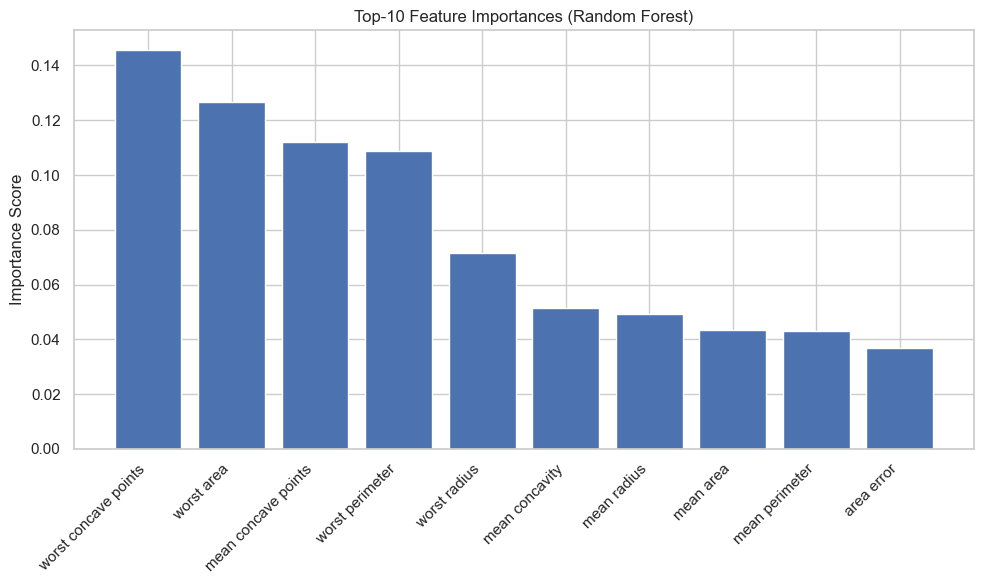

In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(10), importances[indices[:10]])
plt.xticks(range(10), X.columns[indices[:10]], rotation=45, ha="right")
plt.title("Top-10 Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


### Horizontal Bar Plot (Cleaner Presentation)

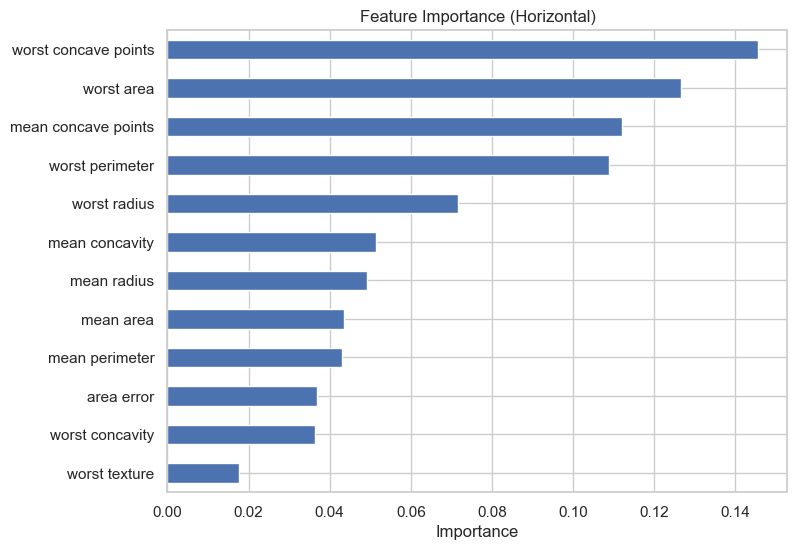

In [4]:
feat_imp = pd.Series(importances, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
feat_imp.tail(12).plot(kind="barh")
plt.title("Feature Importance (Horizontal)")
plt.xlabel("Importance")
plt.show()


### Permutation Feature Importance (Model-Agnostic)
✔ Accuracy Drop Based

ValueError: 'xerr' (shape: (10,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'x' (shape: (1,))

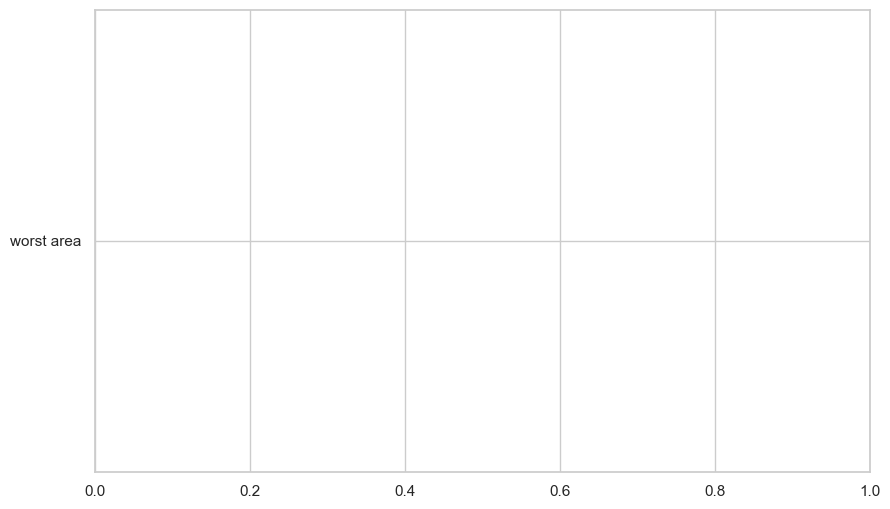

In [5]:
result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame(
    {
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=perm_df.head(10),
    x="importance_mean",
    y="feature",
    xerr=perm_df.head(10)["importance_std"]
)
plt.title("Permutation Feature Importance")
plt.xlabel("Decrease in Accuracy")
plt.show()


### Coefficient-Based Importance (Linear Models)
✔ Logistic Regression (Standardized)

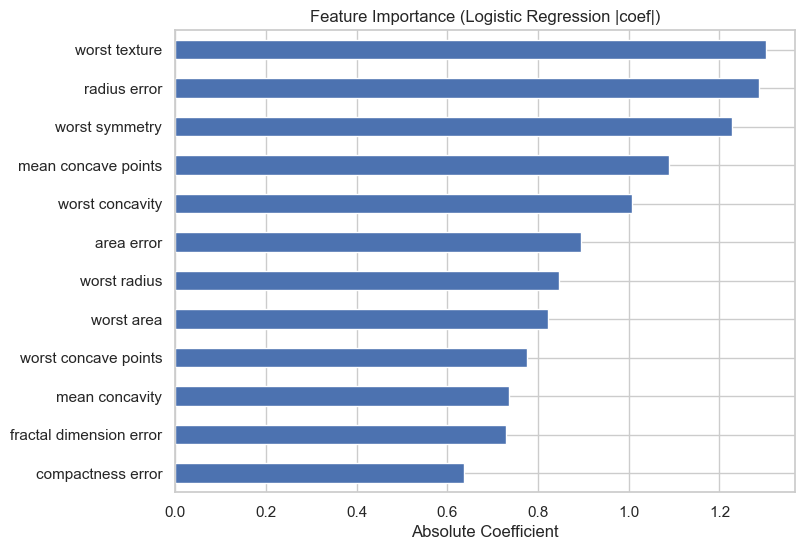

In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=3000)
logreg.fit(X_train_s, y_train)

coef_df = pd.Series(
    np.abs(logreg.coef_[0]),
    index=X.columns
).sort_values()

plt.figure(figsize=(8, 6))
coef_df.tail(12).plot(kind="barh")
plt.title("Feature Importance (Logistic Regression |coef|)")
plt.xlabel("Absolute Coefficient")
plt.show()


### Feature Importance with Error Bars (Stability View)

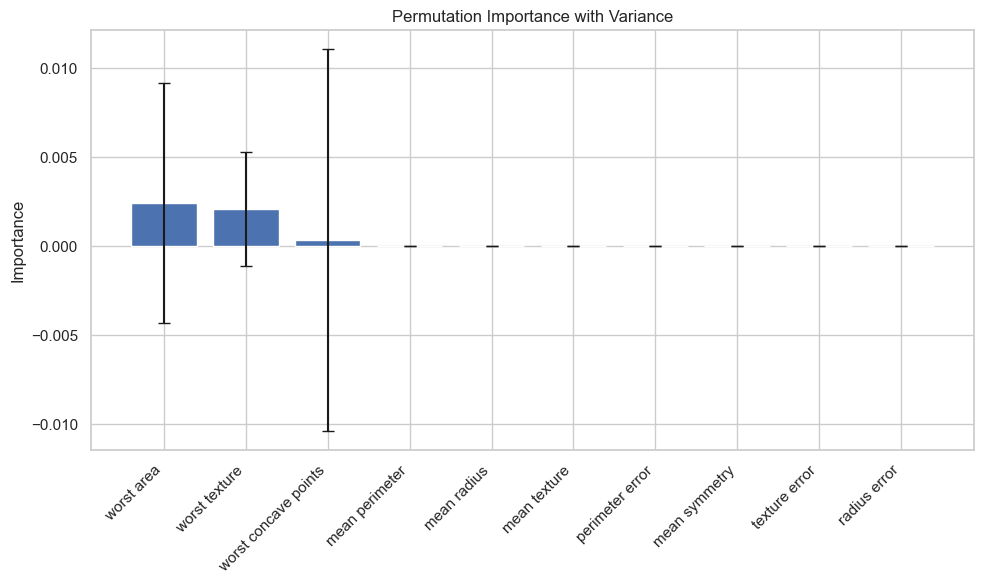

In [7]:
plt.figure(figsize=(10, 6))
plt.bar(
    perm_df.head(10)["feature"],
    perm_df.head(10)["importance_mean"],
    yerr=perm_df.head(10)["importance_std"],
    capsize=4
)
plt.xticks(rotation=45, ha="right")
plt.title("Permutation Importance with Variance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


### Cumulative Importance Curve
✔ How many features explain X% importance?

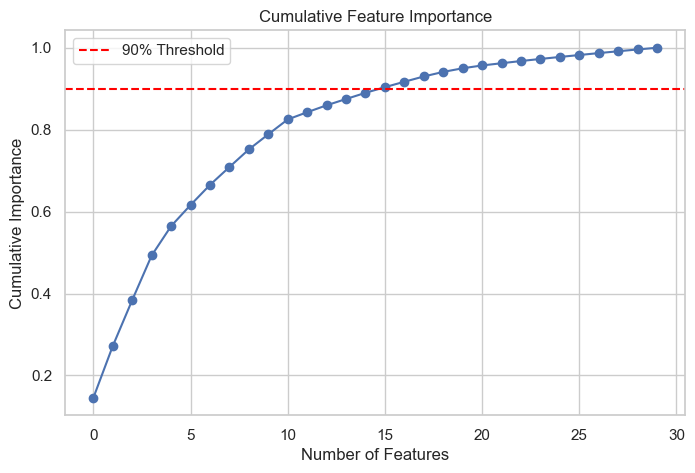

In [8]:
sorted_imp = np.sort(importances)[::-1]
cumulative = np.cumsum(sorted_imp)

plt.figure(figsize=(8, 5))
plt.plot(cumulative, marker="o")
plt.axhline(0.9, color="red", linestyle="--", label="90% Threshold")
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance")
plt.legend()
plt.show()


### Heatmap of Feature Importance Across Models

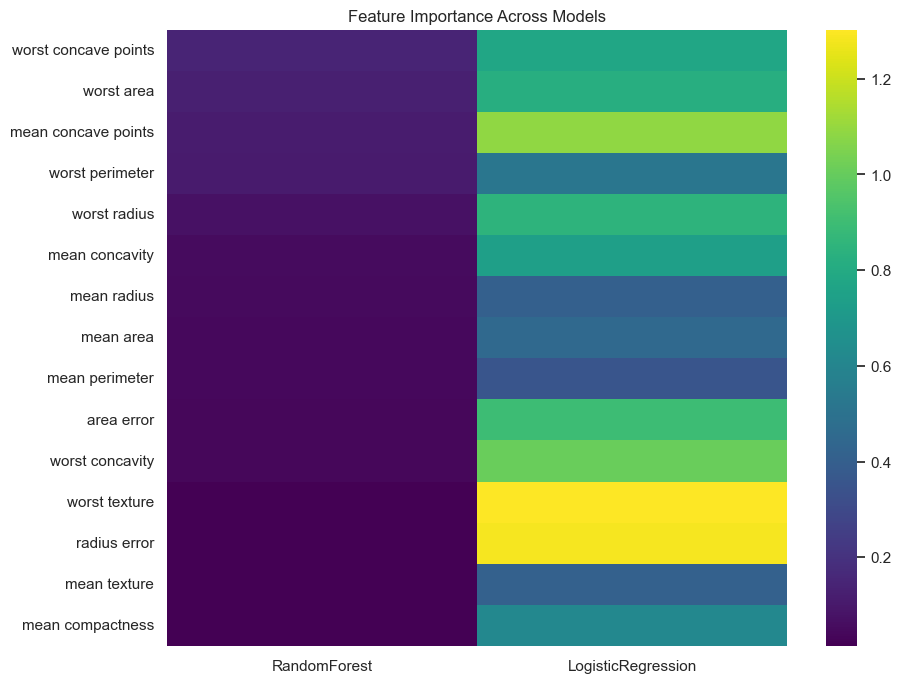

In [9]:
models = {
    "RandomForest": rf.feature_importances_,
    "LogisticRegression": np.abs(logreg.coef_[0])
}

imp_df = pd.DataFrame(models, index=X.columns)

plt.figure(figsize=(10, 8))
sns.heatmap(
    imp_df.nlargest(15, "RandomForest"),
    cmap="viridis",
    annot=False
)
plt.title("Feature Importance Across Models")
plt.show()


### Bootstrap Feature Importance (Advanced & Robust)

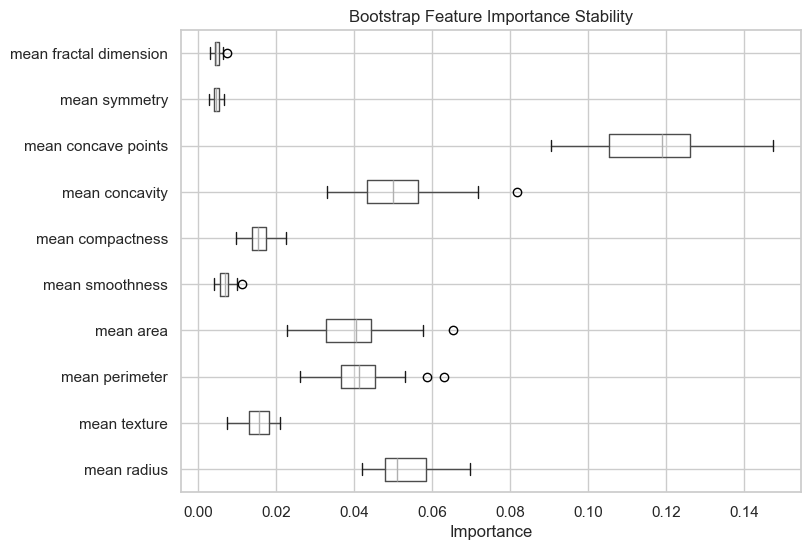

In [10]:
boot_importances = []

for i in range(30):
    Xb, _, yb, _ = train_test_split(
        X_train, y_train, test_size=0.3
    )
    rf.fit(Xb, yb)
    boot_importances.append(rf.feature_importances_)

boot_df = pd.DataFrame(boot_importances, columns=X.columns)

plt.figure(figsize=(8, 6))
boot_df[X.columns[:10]].boxplot(vert=False)
plt.title("Bootstrap Feature Importance Stability")
plt.xlabel("Importance")
plt.show()


### Comparison: Raw vs Permutation Importance

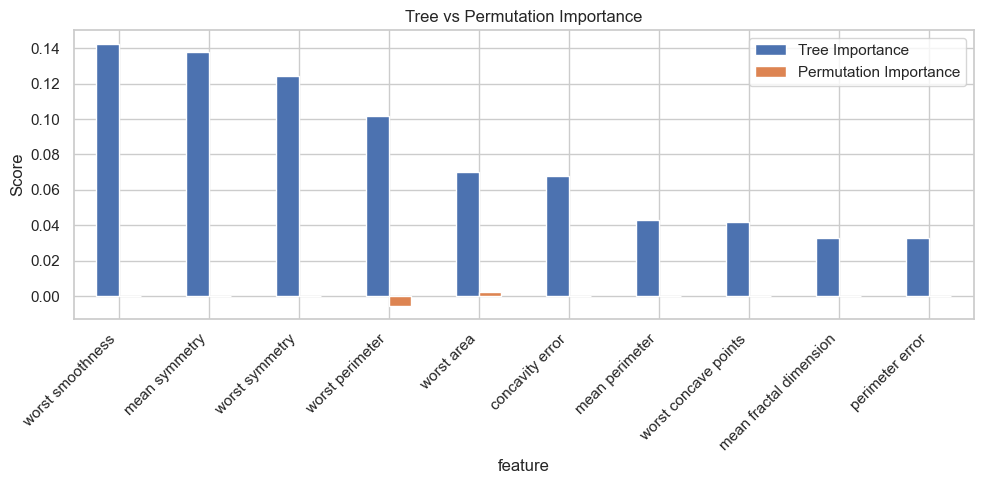

In [11]:
compare_df = pd.DataFrame({
    "Tree Importance": rf.feature_importances_,
    "Permutation Importance": perm_df.set_index("feature")["importance_mean"]
}).dropna()

compare_df = compare_df.sort_values("Tree Importance", ascending=False).head(10)

compare_df.plot(kind="bar", figsize=(10, 5))
plt.title("Tree vs Permutation Importance")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
